# **DIDP model and dual bound declaration**

In [ ]:
%%writefile TSPTW_DIDP_model_declaration.py
import sys
import os
import numpy as np
import modified_didppy as m_dp

# --- GLOBALS ---
current_num_locations = 0
current_travel_cost = []
current_avail_time =[]
current_due_date =[]
# --- READER ---
def read_tsptw_data(file_path):
    """
    Reads TSPTW data from the specified file format:
    - Line 1: Number of locations (N)
    - Next N lines: Distance Matrix (N x N)
    - Next N lines: Time Windows (Ready Time, Due Date)
    - (Ignores subsequent lines, e.g., coordinates)
    """
    with open(file_path, 'r') as f:
        # Read all tokens (whitespace separated) to handle newlines flexibly
        tokens = f.read().split()
    
    iterator = iter(tokens)
    
    try:
        # 1. Number of locations
        num_locations = int(next(iterator))

        # 2. Travel Cost Matrix (N x N)
        travel_cost = []
        for _ in range(num_locations):
            row = []
            for _ in range(num_locations):
                row.append(float(next(iterator))) # Load as float
            travel_cost.append(row)
            
        # 3. Time Windows (N lines of: Ready_Time Due_Date)
        time_windows = []
        for _ in range(num_locations):
            ready = float(next(iterator)) # Load as float
            due = float(next(iterator))   # Load as float
            time_windows.append((ready, due))
        avail_time = [tw[0] for tw in time_windows]
        due_date = [tw[1] for tw in time_windows]
        return num_locations, travel_cost, avail_time, due_date

    except StopIteration:
        raise ValueError(f"Error reading file {file_path}: Unexpected end of file.")

def update_globals_for_tsptw(file_path):
    global current_num_locations, current_travel_cost
    global current_avail_time, current_due_date
    
    num_locations, travel_cost, avail_time, due_date = read_tsptw_data(file_path)
    
    current_num_locations = num_locations
    current_travel_cost = travel_cost
    current_avail_time = avail_time
    current_due_date = due_date
    return True

def creation_of_didp_model_function():
    # Expects global variables: num_locations, dist_matrix, time_windows
    num_locations = current_num_locations
    travel_cost = current_travel_cost
    avail_time = current_avail_time
    due_date = current_due_date
    # 1. Setup Model
    model = m_dp.Model(float_cost=True)
    customer = model.add_object_type(number=num_locations)

    # 2. State Variables
    # unvisited: Set of customers to visit (excluding depot 0)
    unvisited = model.add_set_var(object_type=customer, target=list(range(1, num_locations)))
    # location: Current node
    location = model.add_element_var(object_type=customer, target=0)
    # time: Current cumulative time (resource)
    curr_time = model.add_float_resource_var(target=0.0, less_is_better=True)

    # 3. Data Tables & Helpers
    travel_time_table = model.add_float_table(travel_cost)
    
    # Separate time windows into lists for easy access

    # 4. Transitions: Visit Customer j
    for j in range(1, num_locations):
        visit = m_dp.Transition(
            name="visit {}".format(j),
            cost=travel_time_table[location, j] + m_dp.FloatExpr.state_cost(),
            preconditions=[
                unvisited.contains(j),
                # Feasibility check: Must arrive at j by its Due Date
                # Note: We can arrive early and wait, so we check if arrival <= due_date
                curr_time + travel_time_table[location, j] <= due_date[j]
            ],
            effects=[
                (unvisited, unvisited.remove(j)),
                (location, j),
                # Time update: max(arrival_time, ready_time)
                # arrival_time = curr_time + travel_time
                (curr_time, m_dp.max(curr_time + travel_time_table[location, j], avail_time[j])),
            ],
        )
        model.add_transition(visit)

    # 5. Transition: Return to Depot (0)
    return_to_depot = m_dp.Transition(
        name="return",
        cost=travel_time_table[location, 0] + m_dp.FloatExpr.state_cost(),
        effects=[
            (location, 0),
            (curr_time, curr_time + travel_time_table[location, 0]),
        ],
        preconditions=[
            unvisited.is_empty(), 
            location != 0,
        ],
    )
    model.add_transition(return_to_depot)

    # 6. Base Case
    model.add_base_case([unvisited.is_empty(), location == 0])

    for j in range(1, num_locations):
        model.add_state_constr(
            ~unvisited.contains(j) | (curr_time + travel_time_table[location, j] <= due_date[j])
        )

    # 7. Dual Bounds (Updated for Float Cost)
    # Min outgoing cost from unvisited nodes
    min_to = model.add_float_table(
        [min(travel_cost[k][j] for k in range(num_locations) if k != j) for j in range(num_locations)]
    )
    model.add_dual_bound(min_to[unvisited] + (location != 0).if_then_else(min_to[0], 0.0))

    # Min incoming cost to unvisited nodes
    min_from = model.add_float_table(
        [min(travel_cost[j][k] for k in range(num_locations) if k != j) for j in range(num_locations)]
    )
    model.add_dual_bound(
        min_from[unvisited] + (location != 0).if_then_else(min_from[location], 0.0)
    )

    # 8. Bundle
    metadata = {
        "num_locations": num_locations,
        "distance_matrix": travel_cost,
        "avail_time": avail_time,
        "due_date": due_date,
        "unvisited_var": unvisited,
        "location_var": location,
        "time_var": curr_time
    }
    
    return model, metadata

Overwriting TSPTW_DIDP_model_declaration.py


# **Worker**

In [13]:
%%writefile worker_tsptw_single_bound.py
import sys
import os
import json
import time
import threading
import psutil
import modified_didppy as m_dp

# --- CONFIGURATION ---
MEMORY_LIMIT_MB = 12000

# --- 1. SETUP PATHS ---
# Add current dir to path to find the declaration file
sys.path.append(os.getcwd()) 

# --- 2. IMPORTS ---
try:
    import TSPTW_DIDP_model_declaration as domain 
except ImportError as e:
    print(json.dumps({"status": "error", "message": f"Import Error: {e}"}))
    sys.exit(1)

def memory_guard():
    process = psutil.Process(os.getpid())
    limit_bytes = MEMORY_LIMIT_MB * 1024 * 1024
    while True:
        try:
            if process.memory_info().rss > limit_bytes:
                os._exit(1)
            time.sleep(1)
        except: break

if __name__ == "__main__":
    try:
        threading.Thread(target=memory_guard, daemon=True).start()

        if len(sys.argv) < 4: 
            raise ValueError("Args mismatch: <instance> <data_dir> <time_limit>")
        
        instance_name = sys.argv[1]
        data_dir = sys.argv[2]
        time_limit = float(sys.argv[3])

        file_path = os.path.join(data_dir, instance_name)
        if not os.path.exists(file_path):
             raise FileNotFoundError(f"File not found: {file_path}")
        
        # 1. Update Globals with TSPTW Data
        if not domain.update_globals_for_tsptw(file_path):
             raise ValueError("Failed to load TSPTW globals")

        # 2. Create Model
        model, _ = domain.creation_of_didp_model_function()
        
        # 3. Standard CABS Solver
        # Using the exact logic requested: quiet=False, passed time_limit
        solver = m_dp.CABS(
            model, 
            quiet=False,          # Print logs to stdout (Manager captures this)
            time_limit=time_limit # Set limit
        )
        
        start_time = time.time()
        
        # 4. Run Search
        solution = solver.search()
        
        duration = time.time() - start_time

        # 5. Output Result
        if solution.cost is not None:
            output = {
                "status": "success",
                "cost": solution.cost,
                "expanded": solution.expanded,
                "generated": solution.generated,
                "duration": duration,
                "is_optimal": solution.is_optimal
            }
        else:
            output = {
                "status": "timeout",
                "cost": None,
                "expanded": solution.expanded,
                "generated": solution.generated,
                "duration": duration,
                "is_optimal": False
            }
            
        print("\n" + json.dumps(output))

    except Exception as e:
        # Capture python-level errors as JSON for the manager
        print("\n" + json.dumps({"status": "error", "message": str(e)}))
        sys.exit(1)

Overwriting worker_tsptw_single_bound.py


# **Manager**

In [17]:
import subprocess
import pandas as pd
import numpy as np
import os
import sys
import json

# ==========================================
# CONFIGURATION
# ==========================================
SOLVER_TIME_LIMIT = 900
n_50_signal = True  # <--- TOGGLE THIS: True for n50, False for n20

# Dynamic Configuration based on signal
if n_50_signal:
    DATA_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\2_TSPTW_dual_bounds_and_models\Datasets\n50"
    TARGET_LIST_CSV = "TSPTW_single_dual_bound_50_cus_selected_results_1800s_lim.csv"
    OUTPUT_FOLDER = "TSPTW_Single_Dual_Bound_Results_n50"
else:
    DATA_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\2_TSPTW_dual_bounds_and_models\Datasets\n20"
    TARGET_LIST_CSV = "TSPTW_single_dual_bound_20_cus_selected_results_1800s_lim.csv"
    OUTPUT_FOLDER = "TSPTW_Single_Dual_Bound_Results_n20"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def find_tsptw_file(instance_name):
    """Searches for instance file in configured directory."""
    if not os.path.exists(DATA_DIR): return None
    
    path = os.path.join(DATA_DIR, instance_name)
    if os.path.exists(path): return path
    if os.path.exists(path + ".txt"): return path + ".txt"
    return None

def run_single_bound_experiment():
    dataset_type = "n50" if n_50_signal else "n20"
    print(f"🔹 Starting TSPTW Single Bound Experiment ({dataset_type})...")
    
    # Load Targets
    if not os.path.exists(TARGET_LIST_CSV):
        print(f"❌ Target CSV missing: {TARGET_LIST_CSV}")
        return

    try:
        df = pd.read_csv(TARGET_LIST_CSV)
        target_instances = df['Instance'].tolist()
    except Exception as e:
        print(f"❌ Error reading CSV: {e}")
        return
    
    # Dedup
    target_instances = sorted(list(set(target_instances)))
    print(f"   Targets: {len(target_instances)} instances from {DATA_DIR}")
    
    for i, instance in enumerate(target_instances):
        safe_name = str(instance).replace(".txt", "")
        
        # Paths
        output_txt_path = os.path.join(OUTPUT_FOLDER, f"solver_log_{safe_name}.txt") 
        output_csv_path = os.path.join(OUTPUT_FOLDER, f"result_{safe_name}.csv")
        
        # --- RESUME CHECK ---
        if os.path.exists(output_csv_path):
            print(f"[{i+1}/{len(target_instances)}] Skipping {instance} (CSV exists).")
            continue
        # --------------------

        target_path = find_tsptw_file(str(instance))
        if target_path is None:
            print(f"   ⚠️ Could not find file for {instance} in {DATA_DIR}")
            continue
            
        target_dir = os.path.dirname(target_path)
        target_filename = os.path.basename(target_path)
        
        print(f"\n[{i+1}/{len(target_instances)}] Running {instance}...")
        
        cmd = [
            sys.executable, "-u", "worker_tsptw_single_bound.py",
            target_filename, target_dir, str(SOLVER_TIME_LIMIT)
        ]
        
        try:
            # Run and capture output
            result = subprocess.run(cmd, capture_output=True, text=True)
            
            # 1. Save TXT Log
            with open(output_txt_path, "w", encoding="utf-8") as f:
                f.write(f"Instance: {instance}\n")
                f.write("="*40 + "\n\n")
                f.write(result.stdout)
                if result.stderr:
                    f.write("\n\n=== STDERR ===\n")
                    f.write(result.stderr)
            
            if result.returncode != 0:
                print(f"   ⚠️ Worker Failed (Code {result.returncode})")
                continue

            # 2. Parse JSON and Save CSV
            lines = result.stdout.strip().split('\n')
            json_line = None
            for line in reversed(lines):
                if line.strip().startswith('{') and '"status":' in line:
                    json_line = line
                    break
            
            if json_line:
                data = json.loads(json_line)
                
                if data.get("status") == "error":
                     print(f"   ❌ Worker Error: {data.get('message')}")
                     continue

                # Create DataFrame for this single result
                df_res = pd.DataFrame([{
                    'Instance': instance,
                    'Status': data.get('status'),
                    'Cost': data.get('cost'),
                    'Time (s)': data.get('duration'),
                    'Expanded': data.get('expanded'),
                    'Generated': data.get('generated'),
                    'Is Optimal': data.get('is_optimal')
                }])
                
                df_res.to_csv(output_csv_path, index=False)
                print(f"   ✅ Finished. Saved CSV.")
            else:
                print(f"   ⚠️ Finished but no JSON result found (Log saved).")
            
        except Exception as e:
            print(f"   ❌ Execution Error: {e}")

if __name__ == "__main__":
    run_single_bound_experiment()

🔹 Starting TSPTW Single Bound Experiment (n50)...
   Targets: 20 instances from C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\2_TSPTW_dual_bounds_and_models\Datasets\n50

[1/20] Running 0.txt...
   ✅ Finished. Saved CSV.

[2/20] Running 10.txt...
   ✅ Finished. Saved CSV.

[3/20] Running 12.txt...
   ✅ Finished. Saved CSV.

[4/20] Running 14.txt...
   ✅ Finished. Saved CSV.

[5/20] Running 27.txt...
   ✅ Finished. Saved CSV.

[6/20] Running 29.txt...
   ✅ Finished. Saved CSV.

[7/20] Running 3.txt...
   ✅ Finished. Saved CSV.

[8/20] Running 31.txt...
   ✅ Finished. Saved CSV.

[9/20] Running 46.txt...
   ✅ Finished. Saved CSV.

[10/20] Running 48.txt...
   ✅ Finished. Saved CSV.

[11/20] Running 51.txt...
   ✅ Finished. Saved CSV.

[12/20] Running 52.txt...
   ✅ Finished. Saved CSV.

[13/20] Running 56.txt...
   ✅ Finished. Saved CSV.

[14/20] Running 59.txt...
   ✅ Finished. Saved CSV.

[15/20] Running 64.txt...
   ✅ Finis

🔹 Processing Results in: TSPTW_Single_Dual_Bound_Results_n50
✅ Aggregated 20 summary files into TSPTW_Final_Summary_n50.csv
🔹 Generating Convergence Plot...
✅ Saved gap profile data to TSPTW_Single_Dual_Bound_Results_n50\Average_Gaps_Curve.csv


C:\Users\ACER\AppData\Local\Temp\ipykernel_7308\2634549952.py:167: RuntimeWarning: Mean of empty slice
  mean_gaps = np.nanmean(gap_matrix, axis=0)


✅ Saved plot to TSPTW_Single_Dual_Bound_Results_n50\convergence_plot.png


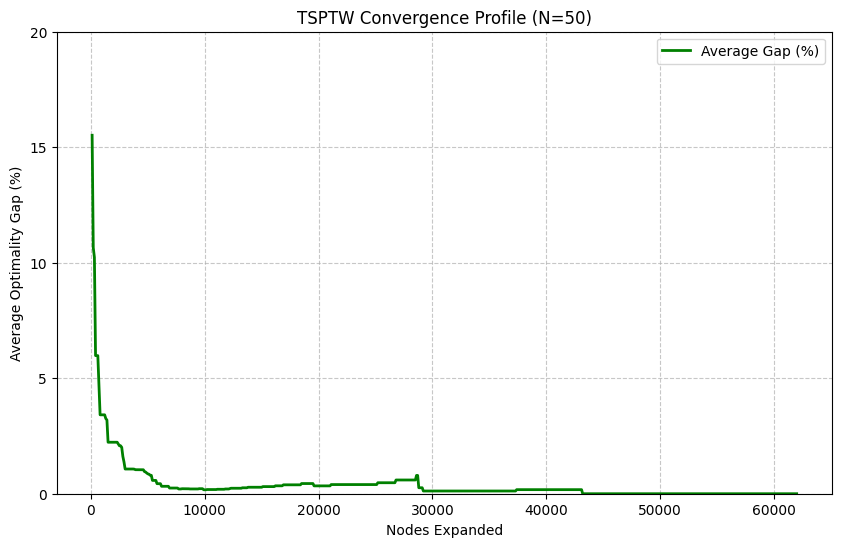

In [18]:
import pandas as pd
import numpy as np
import os
import re
import glob
import math
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ CONFIGURATION (Must match Manager)
# ==========================================
n_50_signal = True  # <--- TOGGLE THIS: True for n50, False for n20

# Settings
NODE_EXPANSION_LIMIT = 100_000 
SAMPLE_STEP = 100 

if n_50_signal:
    OUTPUT_FOLDER = "TSPTW_Single_Dual_Bound_Results_n50"
    FINAL_SUMMARY = "TSPTW_Final_Summary_n50.csv"
    REF_CSV = "TSPTW_single_dual_bound_50_cus_selected_results_1800s_lim.csv"
else:
    OUTPUT_FOLDER = "TSPTW_Single_Dual_Bound_Results_n20"
    FINAL_SUMMARY = "TSPTW_Final_Summary_n20.csv"
    REF_CSV = "TSPTW_single_dual_bound_20_cus_selected_results_1800s_lim.csv"

# ==========================================
# 📊 PART 1: PLOTTING HELPERS
# ==========================================
def parse_solver_log(file_path):
    """Parses solver log to extract (expanded, cost) history."""
    raw_history = []
    current_best_cost = float('inf')
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                # 1. New Primal Bound
                match_primal = re.search(r"New primal bound:\s*([0-9\.\+\-eE]+),\s*expanded:\s*(\d+)", line)
                if match_primal:
                    cost = float(match_primal.group(1))
                    expanded = int(match_primal.group(2))
                    current_best_cost = cost
                    raw_history.append((expanded, cost))
                    if expanded > NODE_EXPANSION_LIMIT: break
                    continue

                # 2. Beam Search Progress
                match_beam = re.search(r"Searched with beam size:.*expanded:\s*(\d+)", line)
                if match_beam:
                    expanded = int(match_beam.group(1))
                    raw_history.append((expanded, current_best_cost))
                    if expanded > NODE_EXPANSION_LIMIT: break
                        
    except Exception:
        pass
    
    # Clean History: Handle duplicates by keeping BEST cost
    raw_history.sort(key=lambda x: x[0])
    cleaned_history = []
    for expanded, cost in raw_history:
        if not cleaned_history:
            cleaned_history.append((expanded, cost))
        else:
            last_expanded, last_cost = cleaned_history[-1]
            if expanded == last_expanded:
                cleaned_history[-1] = (expanded, min(cost, last_cost))
            else:
                cleaned_history.append((expanded, cost))
                
    return cleaned_history

def calculate_dense_gaps(history, optimal_cost, limit):
    """Calculates gap at every SAMPLE_STEP. Cuts off if solver stopped early."""
    max_steps = limit // SAMPLE_STEP
    dense_gaps = np.full(max_steps, np.nan)

    if not history: return dense_gaps

    current_cost = float('inf')
    hist_idx = 0
    max_nodes_reached = history[-1][0]
    
    for i in range(max_steps):
        current_node_count = (i + 1) * SAMPLE_STEP
        
        # CUTOFF LOGIC: Stop filling if we exceed the solver's actual history
        if current_node_count > max_nodes_reached:
            break
        
        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            val = history[hist_idx][1]
            if val < current_cost:
                current_cost = val
            hist_idx += 1
            
        if current_cost != float('inf'):
            denom = optimal_cost if optimal_cost > 0 else 1.0
            gap = (current_cost - optimal_cost) / denom * 100.0
            if gap < 0: gap = 0.0 
            dense_gaps[i] = gap
        
    return dense_gaps

# ==========================================
# 🚀 MAIN AGGREGATION & PLOTTING
# ==========================================
def run_aggregation_and_plotting():
    print(f"🔹 Processing Results in: {OUTPUT_FOLDER}")
    
    if not os.path.exists(OUTPUT_FOLDER):
        print(f"❌ Folder not found: {OUTPUT_FOLDER}")
        return

    # --- 1. AGGREGATE SUMMARY CSVs ---
    csv_files = glob.glob(os.path.join(OUTPUT_FOLDER, "result_*.csv"))
    if csv_files:
        df_list = []
        for f in csv_files:
            try: df_list.append(pd.read_csv(f))
            except: pass
        
        if df_list:
            df_final = pd.concat(df_list, ignore_index=True)
            df_final.sort_values('Instance', inplace=True)
            df_final.to_csv(FINAL_SUMMARY, index=False)
            print(f"✅ Aggregated {len(df_final)} summary files into {FINAL_SUMMARY}")
    else:
        print("⚠️ No result_*.csv files found.")

    # --- 2. GENERATE PLOT FROM LOGS ---
    print("🔹 Generating Convergence Plot...")
    
    # Load BKS
    if not os.path.exists(REF_CSV):
        print(f"❌ Reference CSV missing: {REF_CSV} (Cannot calc gaps)")
        return

    df_ref = pd.read_csv(REF_CSV)
    # Map: "instance" -> optimal_cost
    bks_map = {
        str(row['Instance']).strip().replace(".txt", ""): float(row['Cost'] if 'Cost' in row else row['Best Known Cost'])
        for _, row in df_ref.iterrows()
    }

    log_files = glob.glob(os.path.join(OUTPUT_FOLDER, "solver_log_*.txt"))
    all_dense_gaps = []

    for log_path in log_files:
        name_clean = os.path.basename(log_path).replace("solver_log_", "").replace(".txt", "").strip()
        
        if name_clean not in bks_map:
            continue

        opt_cost = bks_map[name_clean]
        history = parse_solver_log(log_path)
        
        if history:
            dense_gaps = calculate_dense_gaps(history, opt_cost, NODE_EXPANSION_LIMIT)
            all_dense_gaps.append(dense_gaps)

    if all_dense_gaps:
        # Average Gaps
        gap_matrix = np.vstack(all_dense_gaps)
        with np.errstate(invalid='ignore'):
            mean_gaps = np.nanmean(gap_matrix, axis=0)
        
        x_axis = np.arange(SAMPLE_STEP, NODE_EXPANSION_LIMIT + 1, SAMPLE_STEP)
        
        # Save Gap Data
        gap_csv = os.path.join(OUTPUT_FOLDER, "Average_Gaps_Curve.csv")
        pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        }).to_csv(gap_csv, index=False)
        print(f"✅ Saved gap profile data to {gap_csv}")

        # Plotting
        plt.figure(figsize=(10, 6))
        
        # Only plot valid data
        valid_mask = ~np.isnan(mean_gaps)
        if np.any(valid_mask):
            plt.plot(x_axis[valid_mask], mean_gaps[valid_mask], label='Average Gap (%)', color='green', linewidth=2)
            
            max_y = np.max(mean_gaps[valid_mask])
            upper_limit = math.ceil(max_y / 5) * 5
            
            plt.yticks(np.arange(0, upper_limit + 5, 5))
            plt.ylim(0, upper_limit)
            
            plt.xlabel('Nodes Expanded')
            plt.ylabel('Average Optimality Gap (%)')
            plt.title(f'TSPTW Convergence Profile (N={"50" if n_50_signal else "20"})')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend()
            
            plot_path = os.path.join(OUTPUT_FOLDER, "convergence_plot.png")
            plt.savefig(plot_path)
            print(f"✅ Saved plot to {plot_path}")
            plt.show()
        else:
            print("⚠️ Plot skipped: No valid gap data points.")
    else:
        print("⚠️ No log history extracted for plotting.")

if __name__ == "__main__":
    run_aggregation_and_plotting()